In [1]:
!pip install -q transformers datasets scikit-learn tqdm

In [2]:
!pip install -q kaggle

In [3]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from transformers import CLIPProcessor, CLIPModel
from sklearn.metrics import classification_report
from tqdm import tqdm

#checking if colab gave us a GPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
# Replace these with your actual Kaggle details
os.environ['KAGGLE_USERNAME'] = "ayushmadevkota"
os.environ['KAGGLE_KEY'] = "KGAT_089de324cf1b10a587a685dc670d476e"
print("Kaggle credentials set!")

Kaggle credentials set!


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Unzip into the indofashion_data directory
!mkdir -p indofashion_data
!unzip -q /content/drive/MyDrive/minor_project/archive.zip -d indofashion_data

print("IndoFashion dataset downloaded and unzipped successfully!")

IndoFashion dataset downloaded and unzipped successfully!


In [9]:
!ls indofashion_data

archive  __MACOSX


In [10]:
import json

# 1. Load the JSON metadata files from the archive directory
def load_json_lines(path):
    with open(path, "r") as f:
        return [json.loads(line) for line in f]

train_meta = load_json_lines("indofashion_data/archive/train_data.json")
val_meta = load_json_lines("indofashion_data/archive/val_data.json")
test_meta = load_json_lines("indofashion_data/archive/test_data.json")

# Extract unique class names (e.g., saree, kurti, etc.)
label_names = sorted(list(set(item["class_label"] for item in train_meta)))
label2id = {name: i for i, name in enumerate(label_names)}
id2label = {i: name for i, name in enumerate(label_names)}
num_classes = len(label_names)

print(f"Total classes found ({num_classes}): {label_names}")

# 2. Download pre-trained FashionCLIP model and processor
print("\nLoading FashionCLIP model...")
MODEL_NAME = "patrickjohncyh/fashion-clip"

clip_processor = CLIPProcessor.from_pretrained(MODEL_NAME)
clip_model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)

# 3. Freeze FashionCLIP parameters
clip_model.eval()
for param in clip_model.parameters():
    param.requires_grad = False

print("FashionCLIP loaded and frozen successfully!")

Total classes found (15): ['blouse', 'dhoti_pants', 'dupattas', 'gowns', 'kurta_men', 'leggings_and_salwars', 'lehenga', 'mojaris_men', 'mojaris_women', 'nehru_jackets', 'palazzos', 'petticoats', 'saree', 'sherwanis', 'women_kurta']

Loading FashionCLIP model...


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.46k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/568 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

FashionCLIP loaded and frozen successfully!


In [14]:
from PIL import Image

class IndoFashionDataset(Dataset):
    def __init__(self, metadata, base_dir="indofashion_data/archive"):
        self.metadata = metadata
        self.base_dir = base_dir

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        item = self.metadata[idx]
        image_path = os.path.join(self.base_dir, item["image_path"])

        try:
            image = Image.open(image_path).convert("RGB")
        except FileNotFoundError:
            # Fallback if image path has slight name/extension mismatch
            print(f"\n[Warning] File missing: {image_path}, skipping/using blank placeholder.")
            image = Image.new("RGB", (224, 224), color="black")

        label = label2id[item["class_label"]]
        return image, label

def collate_fn(batch):
    images = [item[0] for item in batch]
    labels = torch.tensor([item[1] for item in batch])
    return images, labels

def extract_features(metadata, split_name):
    print(f"Extracting features for {split_name} split...")
    dataset = IndoFashionDataset(metadata)
    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fn
    )

    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Processing {split_name}"):
            inputs = clip_processor(images=images, return_tensors="pt", padding=True).to(DEVICE)
            outputs = clip_model.get_image_features(**inputs)

            if hasattr(outputs, "image_embeds"):
                image_features = outputs.image_embeds
            elif hasattr(outputs, "pooler_output"):
                image_features = outputs.pooler_output
            else:
                image_features = outputs

            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            all_features.append(image_features.cpu())
            all_labels.append(labels)

    X = torch.cat(all_features, dim=0)
    y = torch.cat(all_labels, dim=0)
    return X, y

# Extract features for Train, Validation, and Test splits
X_train, y_train = extract_features(train_meta, "train")
X_val, y_val = extract_features(val_meta, "validation")
X_test, y_test = extract_features(test_meta, "test")

# Save extracted feature tensors to disk
os.makedirs("extracted_features", exist_ok=True)
torch.save({"X": X_train, "y": y_train}, "extracted_features/train.pt")
torch.save({"X": X_val, "y": y_val}, "extracted_features/val.pt")
torch.save({"X": X_test, "y": y_test}, "extracted_features/test.pt")

print("Feature extraction complete! Tensors saved successfully.")

Extracting features for train split...


Processing train: 100%|██████████| 1425/1425 [10:54<00:00,  2.18it/s]


Extracting features for validation split...


Processing validation: 100%|██████████| 118/118 [00:57<00:00,  2.07it/s]


Extracting features for test split...


...


[Warning] File missing: indofashion_data/archive/images/test/1486.jpeg, skipping/using blank placeholder.


Processing test:  90%|████████▉ | 106/118 [00:53<00:05,  2.15it/s]


[Warning] File missing: indofashion_data/archive/images/test/7047.jpeg, skipping/using blank placeholder.


Processing test: 100%|██████████| 118/118 [00:57<00:00,  2.06it/s]


Feature extraction complete! Tensors saved successfully.


In [15]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset

# load the pre-extracted feature tensors
train_data = torch.load("extracted_features/train.pt")
val_data = torch.load("extracted_features/val.pt")
test_data = torch.load("extracted_features/test.pt")

train_loader = DataLoader(TensorDataset(train_data["X"], train_data["y"]), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(val_data["X"], val_data["y"]), batch_size=128, shuffle=False)

# define our lightweight Classification Head
class FashionClassifierHead(nn.Module):
    def __init__(self, input_dim=512, num_classes=15):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

model = FashionClassifierHead(input_dim=512, num_classes=num_classes).to(DEVICE)

#loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

#training Loop
EPOCHS = 10
print("Starting training on extracted features...\n")

for epoch in range(EPOCHS):
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_acc = correct / total

    #validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss/total:.4f} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

# save the trained classifier weights
torch.save(model.state_dict(), "indofashion_head.pth")
print("\nTrained model weights saved as 'indofashion_head.pth'!")

Starting training on extracted features...

Epoch 01/10 | Train Loss: 0.7084 | Train Acc: 79.59% | Val Acc: 85.75%
Epoch 02/10 | Train Loss: 0.4107 | Train Acc: 87.20% | Val Acc: 87.32%
Epoch 03/10 | Train Loss: 0.3797 | Train Acc: 88.21% | Val Acc: 87.71%
Epoch 04/10 | Train Loss: 0.3611 | Train Acc: 88.81% | Val Acc: 88.05%
Epoch 05/10 | Train Loss: 0.3478 | Train Acc: 89.16% | Val Acc: 87.92%
Epoch 06/10 | Train Loss: 0.3355 | Train Acc: 89.56% | Val Acc: 88.33%
Epoch 07/10 | Train Loss: 0.3269 | Train Acc: 89.72% | Val Acc: 88.53%
Epoch 08/10 | Train Loss: 0.3190 | Train Acc: 89.96% | Val Acc: 88.64%
Epoch 09/10 | Train Loss: 0.3113 | Train Acc: 90.27% | Val Acc: 88.59%
Epoch 10/10 | Train Loss: 0.3060 | Train Acc: 90.36% | Val Acc: 88.71%

Trained model weights saved as 'indofashion_head.pth'!


In [16]:
from sklearn.metrics import classification_report, accuracy_score

# loading test data loader
test_loader = DataLoader(TensorDataset(test_data["X"], test_data["y"]), batch_size=128, shuffle=False)

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.numpy())

test_acc = accuracy_score(all_targets, all_preds)
print(f"Final Test Accuracy: {test_acc * 100:.2f}%\n")

target_names = [id2label[i] for i in range(num_classes)]
print("Classification Report:\n")
print(classification_report(all_targets, all_preds, target_names=target_names))

Final Test Accuracy: 88.93%

Classification Report:

                      precision    recall  f1-score   support

              blouse       0.98      0.98      0.98       500
         dhoti_pants       0.92      0.73      0.82       500
            dupattas       0.85      0.77      0.81       500
               gowns       0.86      0.61      0.71       500
           kurta_men       0.92      0.96      0.94       500
leggings_and_salwars       0.79      0.92      0.85       500
             lehenga       0.96      0.96      0.96       500
         mojaris_men       0.92      0.88      0.90       500
       mojaris_women       0.89      0.93      0.91       500
       nehru_jackets       0.98      0.99      0.98       500
            palazzos       0.98      0.91      0.94       500
          petticoats       0.98      0.90      0.94       500
               saree       0.86      0.97      0.91       500
           sherwanis       0.97      0.92      0.94       500
         women_k

In [17]:
from google.colab import files
files.download("indofashion_head.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

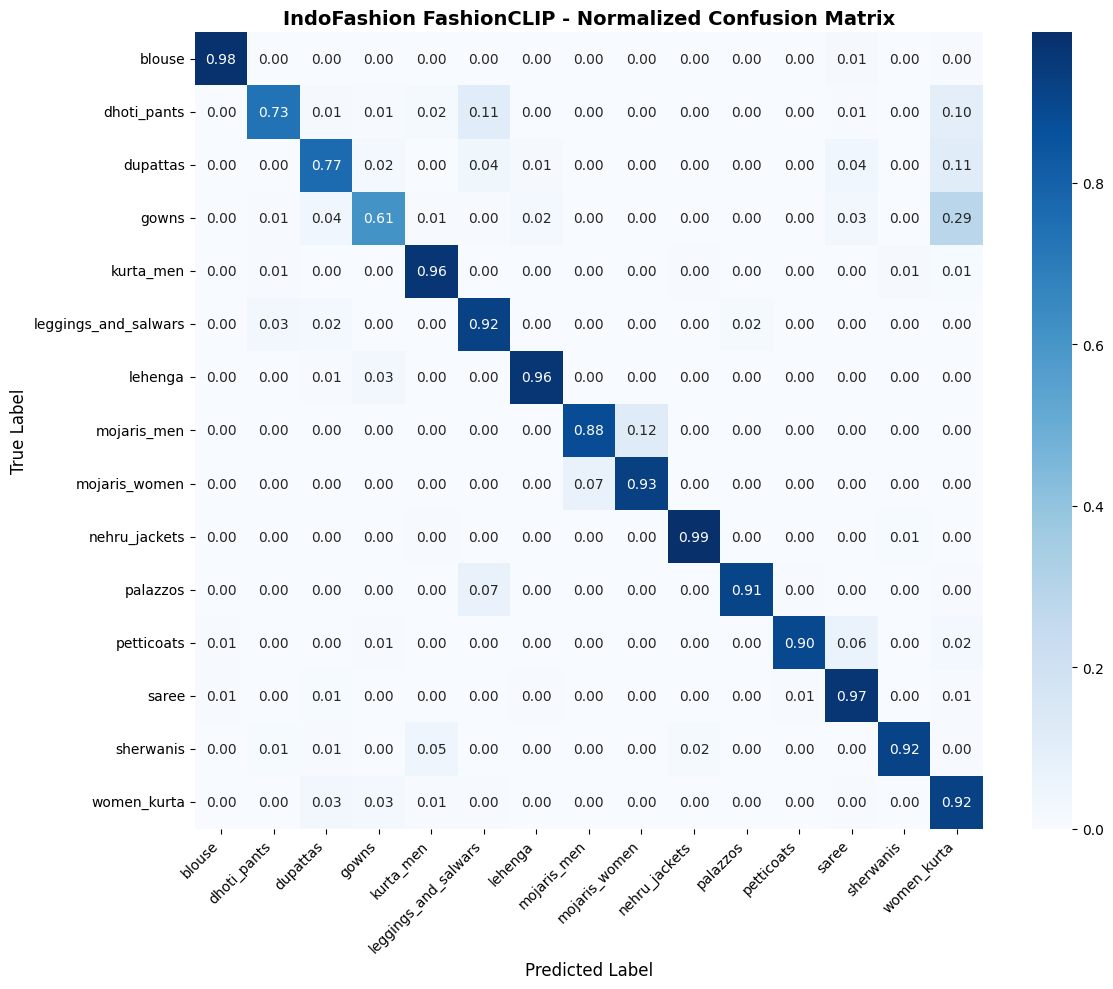

Confusion matrix saved as 'indofashion_confusion_matrix.png'!


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute normalized confusion matrix
cm = confusion_matrix(all_targets, all_preds, normalize='true')

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('IndoFashion FashionCLIP - Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save figure for report documentation
plt.savefig("indofashion_confusion_matrix.png", dpi=300)
plt.show()

print("Confusion matrix saved as 'indofashion_confusion_matrix.png'!")

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image

class IndoFashionService:
    def __init__(self, model_path, clip_model, clip_processor, id2label, device=None, temperature=1.2, confidence_threshold=0.50):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.clip_model = clip_model.to(self.device).eval()
        self.clip_processor = clip_processor
        self.id2label = id2label
        self.temperature = temperature
        self.confidence_threshold = confidence_threshold

        # Initialize head architecture
        self.head = FashionClassifierHead(input_dim=512, num_classes=len(id2label)).to(self.device)
        self.head.load_state_dict(torch.load(model_path, map_location=self.device))
        self.head.eval()

    def predict(self, image_input):
        """
        Accepts PIL Image or file path.
        Returns predicted category, confidence score, and low-confidence flag.
        """
        if isinstance(image_input, str):
            image = Image.open(image_input).convert("RGB")
        else:
            image = image_input.convert("RGB")

        inputs = self.clip_processor(images=image, return_tensors="pt", padding=True).to(self.device)

        with torch.no_grad():
            outputs = self.clip_model.get_image_features(**inputs)

            # Unpack raw tensor reliably
            if hasattr(outputs, "image_embeds") and outputs.image_embeds is not None:
                features = outputs.image_embeds
            elif hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                features = outputs.pooler_output
            elif isinstance(outputs, torch.Tensor):
                features = outputs
            else:
                features = outputs[0]

            # L2 Normalization
            features = features / features.norm(dim=-1, keepdim=True)

            logits = self.head(features)

            # Apply Temperature Scaling
            scaled_logits = logits / self.temperature
            probs = F.softmax(scaled_logits, dim=-1)

            confidence, pred_id = torch.max(probs, dim=-1)
            confidence_val = confidence.item()
            pred_class = self.id2label[pred_id.item()]

            is_flagged = confidence_val < self.confidence_threshold

        return {
            "prediction": pred_class,
            "confidence": round(confidence_val, 4),
            "flagged_low_confidence": is_flagged,
            "all_probabilities": {self.id2label[i]: round(probs[0][i].item(), 4) for i in range(len(self.id2label))}
        }

# Re-instantiate service instance
classifier_service = IndoFashionService(
    model_path="indofashion_head.pth",
    clip_model=clip_model,
    clip_processor=clip_processor,
    id2label=id2label,
    device=DEVICE,
    temperature=1.2,
    confidence_threshold=0.50
)

print("IndoFashion Inference Service updated and ready!")

IndoFashion Inference Service updated and ready!


In [23]:
# Test on a single test dataset image
sample_image_path = "download.png" # or any test image path
result = classifier_service.predict(sample_image_path)

print("\n--- Prediction Output ---")
print(f"Predicted Class : {result['prediction']}")
print(f"Confidence      : {result['confidence'] * 100:.2f}%")
print(f"Needs Review    : {result['flagged_low_confidence']}")


--- Prediction Output ---
Predicted Class : dupattas
Confidence      : 33.28%
Needs Review    : True


In [24]:
%%writefile indofashion_service.py
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

# 1. Classification Head Architecture
class FashionClassifierHead(nn.Module):
    def __init__(self, input_dim=512, num_classes=15):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)


# 2. Production Inference Service
class IndoFashionService:
    def __init__(
        self,
        model_path="ml_experiments/indofashion_head.pth",
        model_name="patrickjohncyh/fashion-clip",
        id2label=None,
        device=None,
        temperature=1.2,
        confidence_threshold=0.50
    ):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Default 15 IndoFashion categories if none provided
        self.id2label = id2label or {
            0: 'blouse', 1: 'dhoti_pants', 2: 'dupattas', 3: 'gowns',
            4: 'kurta_men', 5: 'leggings_and_salwars', 6: 'lehenga', 7: 'mojaris_men',
            8: 'mojaris_women', 9: 'nehru_jackets', 10: 'palazzos', 11: 'petticoats',
            12: 'saree', 13: 'sherwanis', 14: 'women_kurta'
        }

        self.temperature = temperature
        self.confidence_threshold = confidence_threshold

        # Load backbone FashionCLIP model & processor
        self.clip_processor = CLIPProcessor.from_pretrained(model_name)
        self.clip_model = CLIPModel.from_pretrained(model_name).to(self.device)
        self.clip_model.eval()

        # Load classification head weights
        self.head = FashionClassifierHead(input_dim=512, num_classes=len(self.id2label)).to(self.device)
        self.head.load_state_dict(torch.load(model_path, map_location=self.device))
        self.head.eval()

    def predict(self, image_input):
        """
        Accepts a PIL Image instance or a file path string.
        Returns predicted category, calibrated confidence, low-confidence flag, and probability distribution.
        """
        if isinstance(image_input, str):
            image = Image.open(image_input).convert("RGB")
        else:
            image = image_input.convert("RGB")

        inputs = self.clip_processor(images=image, return_tensors="pt", padding=True).to(self.device)

        with torch.no_grad():
            outputs = self.clip_model.get_image_features(**inputs)

            # Robust tensor unpacking
            if hasattr(outputs, "image_embeds") and outputs.image_embeds is not None:
                features = outputs.image_embeds
            elif hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                features = outputs.pooler_output
            elif isinstance(outputs, torch.Tensor):
                features = outputs
            else:
                features = outputs[0]

            # L2 Normalization
            features = features / features.norm(dim=-1, keepdim=True)

            logits = self.head(features)

            # Temperature Scaling
            scaled_logits = logits / self.temperature
            probs = F.softmax(scaled_logits, dim=-1)

            confidence, pred_id = torch.max(probs, dim=-1)
            confidence_val = confidence.item()
            pred_class = self.id2label[pred_id.item()]

            is_flagged = confidence_val < self.confidence_threshold

        return {
            "prediction": pred_class,
            "confidence": round(confidence_val, 4),
            "flagged_low_confidence": is_flagged,
            "all_probabilities": {
                self.id2label[i]: round(probs[0][i].item(), 4) for i in range(len(self.id2label))
            }
        }

Writing indofashion_service.py
